# GABLS3 LES Intercomparison Study for Stable Boundary Layers: Horizontal Cross-Sectional Views

In [1]:
from IPython.display import display, Markdown
from datetime import datetime, timezone
display(Markdown(f"*Last run: {datetime.now(timezone.utc).strftime('%B %d, %Y at %H:%M UTC')}*"))

*Last run: June 24, 2026 at 09:27 UTC*

**Case Description:** This notebook shows horizontal (x-y plane) cross-sections of the velocity components ($u$, $v$, $w$) and potential temperature ($\theta$) from the GABLS3 nocturnal stable boundary-layer benchmark at Cabauw. Cross-sections are extracted at four height levels near $l_z/20$, $l_z/10$, $l_z/5$, and $l_z/3$. The 3D fields are sampled at the configured final time from `Config.py` using the reference run `256x256x256_LASDD_SM_SP`.

**Load the necessary packages**

In [1]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

**Input & Output Directories**

In [2]:
# Base directory (jaxalfa/)
from pathlib import Path
def find_repo_root(start=None):
    path = Path(start or ('__file__' in globals() and __file__) or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'examples').is_dir() and (candidate / 'docs').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate jaxalfa repository root')

BaseDir = find_repo_root()

# Reference run: 256x256x256 LASDD-SM single precision
RunDir    = BaseDir / 'examples/SBL_GABLS3/runs/256x256x256_LASDD_SM_SP'
OutputDir = RunDir / 'output'

cfg = {}
exec((RunDir / 'Config.py').read_text(), cfg)


**Load 3D fields from the configured final time**

In [3]:
T_snapshot = float(cfg['SimTime'])  # unit: sec
dt = float(cfg['dt'])
iter_3D = int(T_snapshot / dt)
field_path = OutputDir / f'ALFA_3DFields_Iteration_{iter_3D}.npz'

if field_path.exists():
    File3D = np.load(field_path)
    u3D  = File3D['u']
    v3D  = File3D['v']
    w3D  = File3D['w']
    TH3D = File3D['TH']
else:
    nx = int(cfg['nx']); ny = int(cfg['ny']); nz = int(cfg['nz'])
    print(f'Missing {field_path}; plotting NaN placeholders for this run.')
    u3D = np.full((nx, ny, nz), np.nan)
    v3D = np.full((nx, ny, nz), np.nan)
    w3D = np.full((nx, ny, nz), np.nan)
    TH3D = np.full((nx, ny, nz), np.nan)


**Input Information from the Config File**

In [4]:
l_x = float(cfg['l_x'])
l_y = float(cfg['l_y'])
l_z = float(cfg['l_z'])
z_damping = float(cfg.get('z_damping', np.nan))
SimTime = float(cfg['SimTime'])

nx = int(cfg['nx'])
ny = int(cfg['ny'])
nz = int(cfg['nz'])
dx = l_x / nx
dy = l_y / ny
dz = l_z / (nz - 1)
x_axis = dx * np.arange(nx)
y_axis = dy * np.arange(ny)


**Derived Variables**

In [5]:
# Half levels for u, v, TH variables
z_u = np.array([(k + 0.5) * l_z / (nz - 1) for k in range(nz)])

# Full levels for w
z_w = np.array([k * l_z / (nz - 1) for k in range(nz)])

**Plot horizontal cross-section of longitudinal velocity fields**

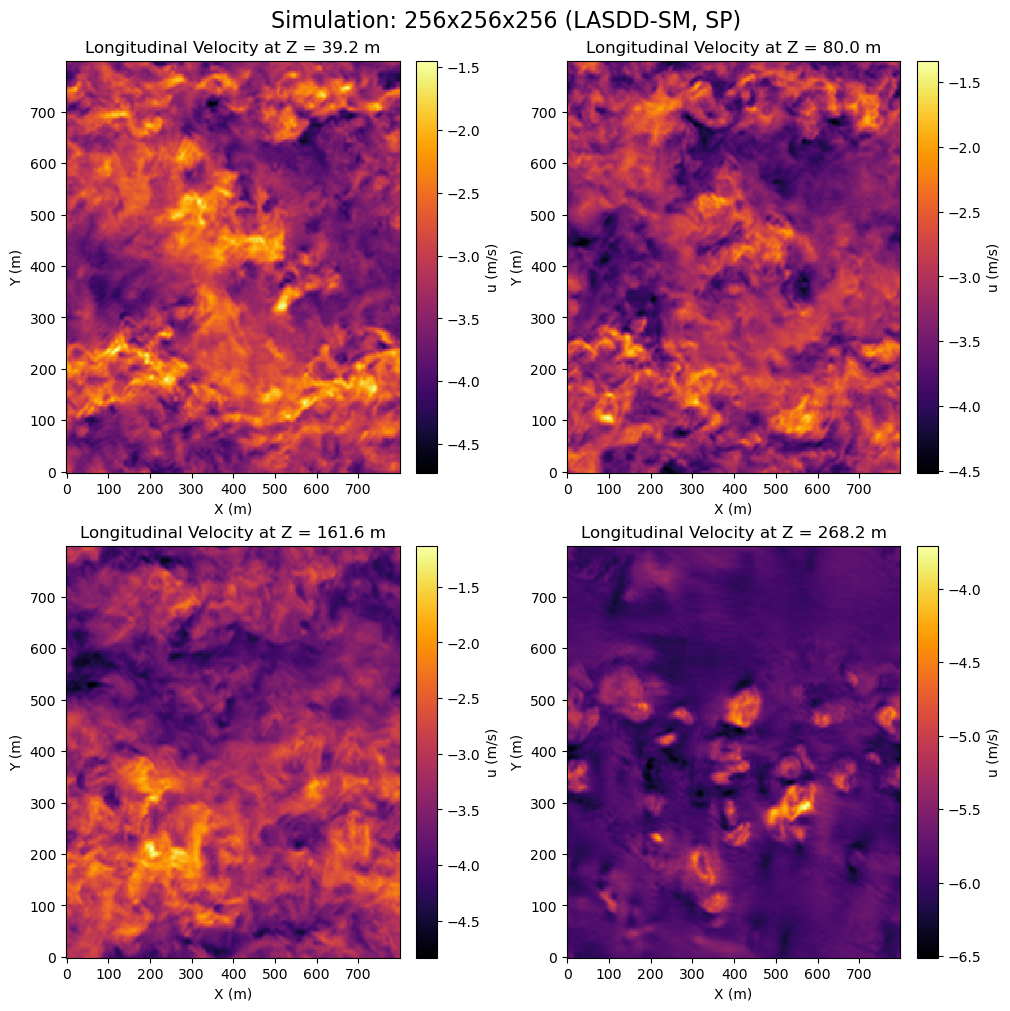

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
axes = axes.flatten()

# Selected cross-sections at l_z/20, l_z/10, l_z/5, and l_z/3
k_levels = [int(nz/20), int(nz/10), int(nz/5), int(nz/3)]

for i, k in enumerate(k_levels):
    im = axes[i].pcolor(x_axis, y_axis, u3D[:,:,k].T, cmap='inferno')
    axes[i].set_title(f'Longitudinal Velocity at Z = {z_u[k]:.1f} m',
                      fontsize=12)
    axes[i].set_xlabel('X (m)')
    axes[i].set_ylabel('Y (m)')
    axes[i].set_aspect('auto')
    fig.colorbar(im, ax=axes[i], label='u (m/s)')

plt.suptitle('Simulation: 256x256x256 (LASDD-SM, SP)', fontsize=16)
plt.show()

**Plot horizontal cross-section of lateral velocity fields**

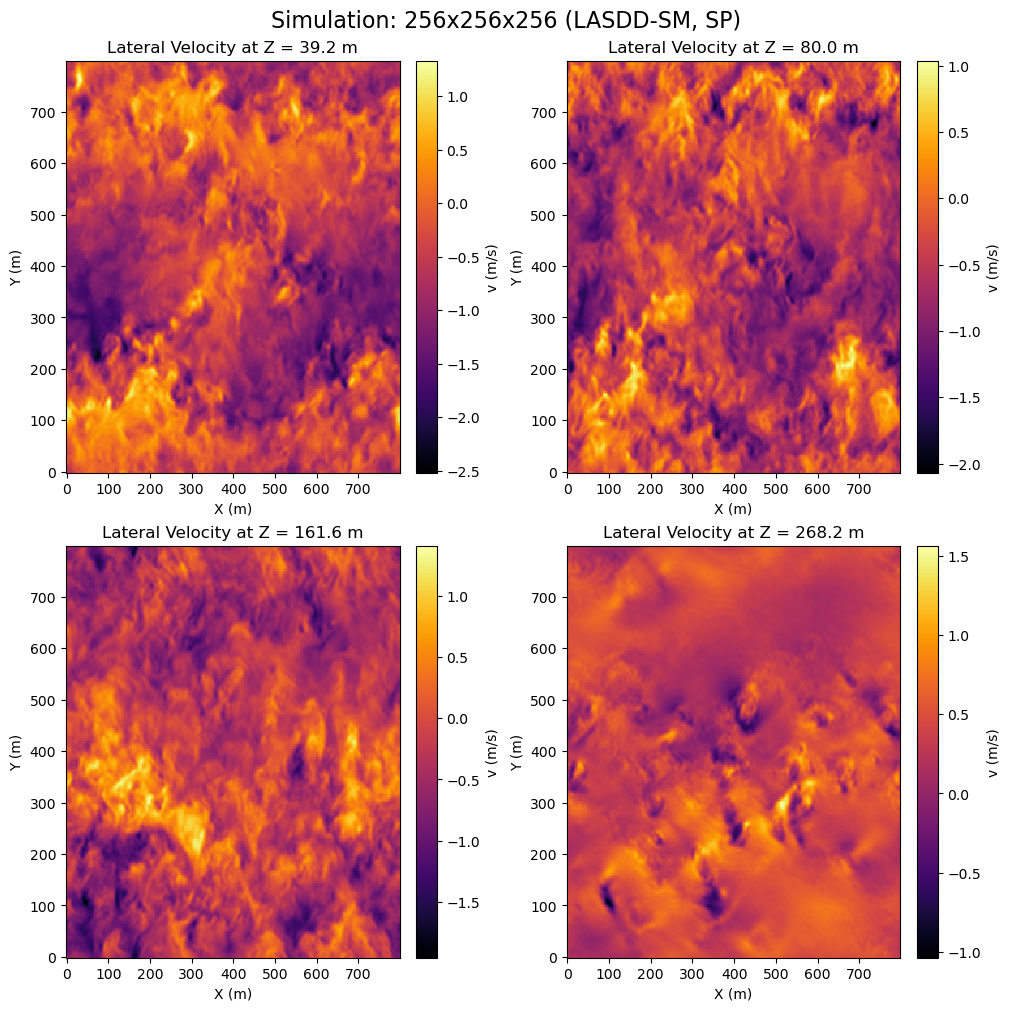

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
axes = axes.flatten()

# Selected cross-sections at l_z/20, l_z/10, l_z/5, and l_z/3
k_levels = [int(nz/20), int(nz/10), int(nz/5), int(nz/3)]

for i, k in enumerate(k_levels):
    im = axes[i].pcolor(x_axis, y_axis, v3D[:,:,k].T, cmap='inferno')
    axes[i].set_title(f'Lateral Velocity at Z = {z_u[k]:.1f} m',
                      fontsize=12)
    axes[i].set_xlabel('X (m)')
    axes[i].set_ylabel('Y (m)')
    axes[i].set_aspect('auto')
    fig.colorbar(im, ax=axes[i], label='v (m/s)')

plt.suptitle('Simulation: 256x256x256 (LASDD-SM, SP)', fontsize=16)
plt.show()

**Plot horizontal cross-section of vertical velocity fields**

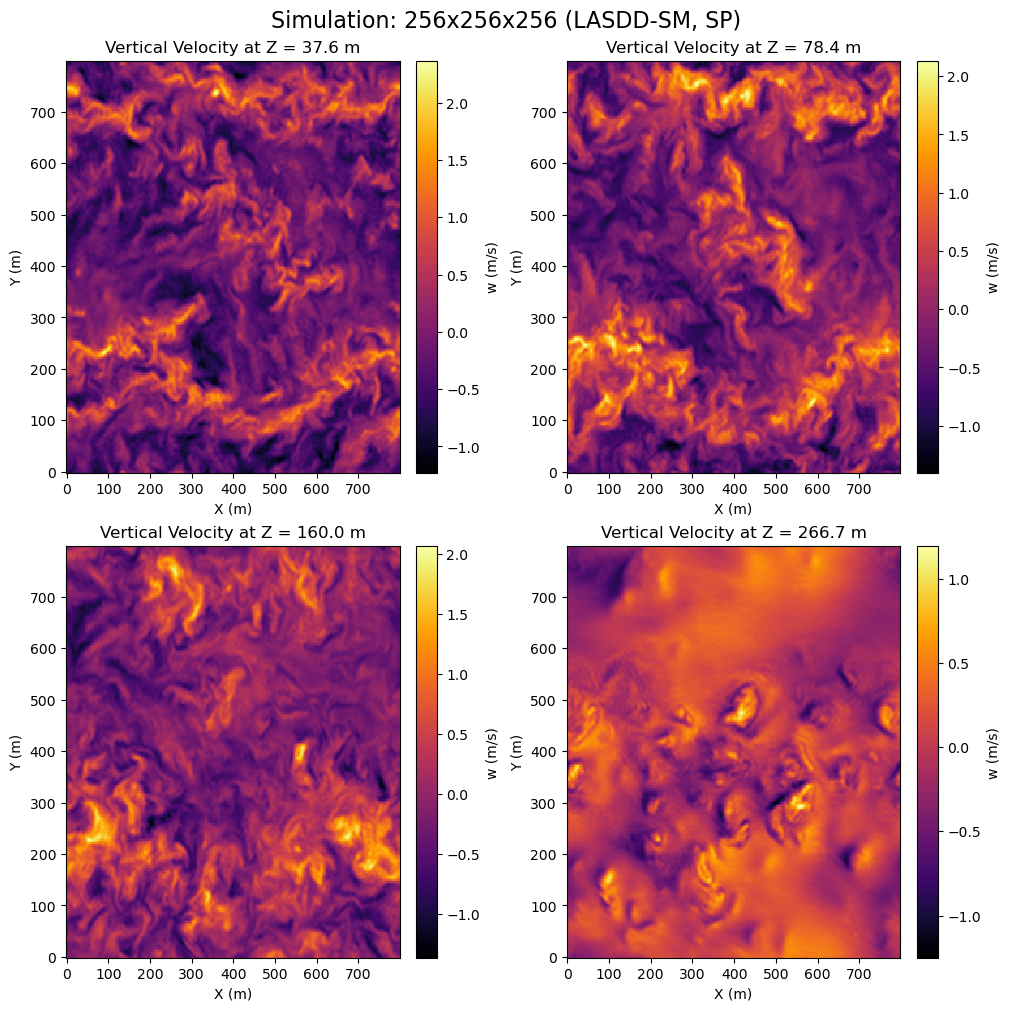

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
axes = axes.flatten()

# Selected cross-sections at l_z/20, l_z/10, l_z/5, and l_z/3
k_levels = [int(nz/20), int(nz/10), int(nz/5), int(nz/3)]

for i, k in enumerate(k_levels):
    im = axes[i].pcolor(x_axis, y_axis, w3D[:,:,k].T, cmap='inferno')
    axes[i].set_title(f'Vertical Velocity at Z = {z_w[k]:.1f} m',
                      fontsize=12)
    axes[i].set_xlabel('X (m)')
    axes[i].set_ylabel('Y (m)')
    axes[i].set_aspect('auto')
    fig.colorbar(im, ax=axes[i], label='w (m/s)')

plt.suptitle('Simulation: 256x256x256 (LASDD-SM, SP)', fontsize=16)
plt.show()

**Plot horizontal cross-section of potential temperature fields**

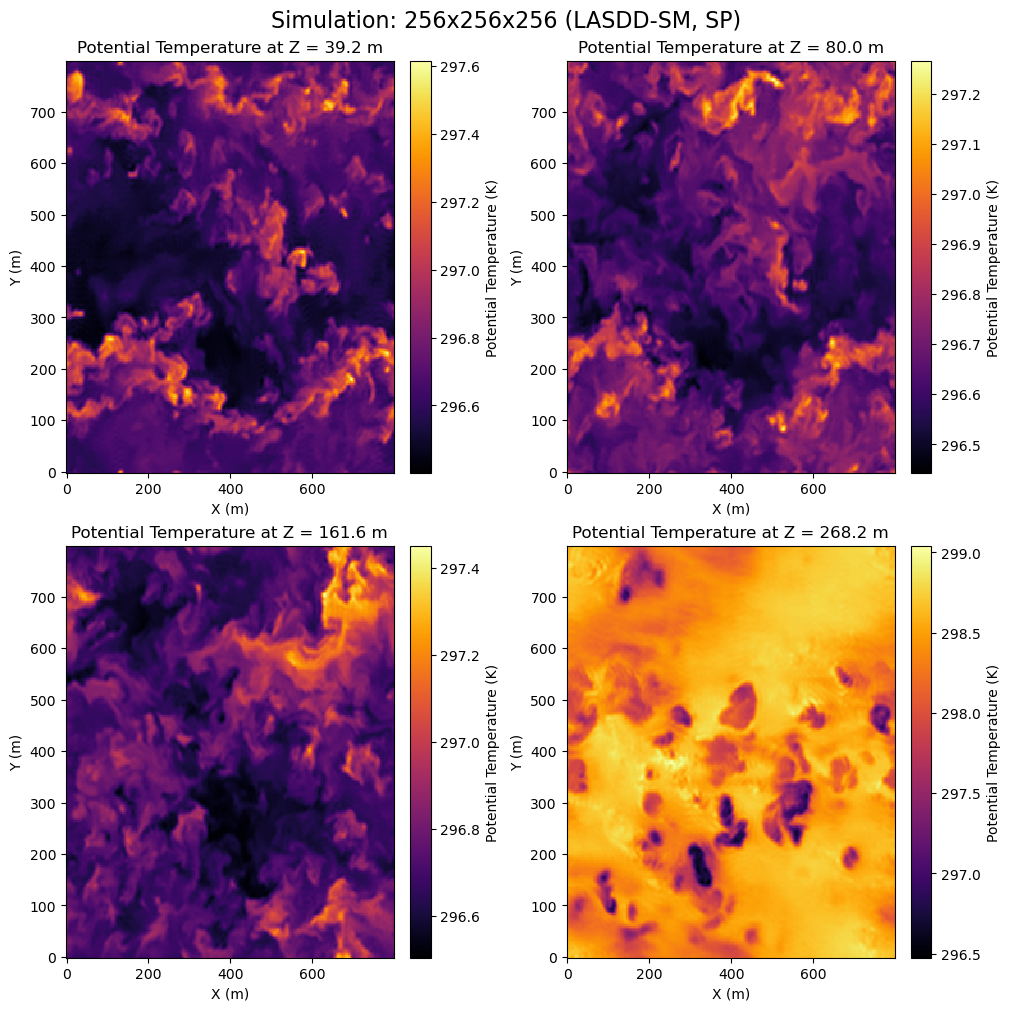

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
axes = axes.flatten()

# Selected cross-sections at l_z/20, l_z/10, l_z/5, and l_z/3
k_levels = [int(nz/20), int(nz/10), int(nz/5), int(nz/3)]

for i, k in enumerate(k_levels):
    im = axes[i].pcolor(x_axis, y_axis, TH3D[:,:,k].T, cmap='inferno')
    axes[i].set_title(f'Potential Temperature at Z = {z_u[k]:.1f} m',
                      fontsize=12)
    axes[i].set_xlabel('X (m)')
    axes[i].set_ylabel('Y (m)')
    axes[i].set_aspect('auto')
    fig.colorbar(im, ax=axes[i], label='Potential Temperature (K)')

plt.suptitle('Simulation: 256x256x256 (LASDD-SM, SP)', fontsize=16)
plt.show()